# Домашнє завдання: Прогнозування кредитного ризику

## Мета завдання
Застосувати знання з лекції для побудови моделі логістичної регресії, що прогнозує ймовірність дефолту за кредитом, іншими словами, що людина не поверне кредит. Ви пройдете весь цикл: від дослідницького аналізу до оцінки якості класифікаційної моделі.

## Опис датасету
**Credit Risk Dataset** містить інформацію про 32,000+ позичальників з такими параметрами:
- **person_age**: Вік позичальника
- **person_income**: Річний дохід
- **person_home_ownership**: Тип володіння житлом
- **person_emp_length**: Стаж роботи (в роках)
- **loan_intent**: Мета кредиту
- **loan_grade**: Кредитний рейтинг (A - кращий, F - гірший)
- **loan_amnt**: Сума кредиту
- **loan_int_rate**: Процентна ставка
- **loan_status**: Статус кредиту (0 = сплачено, 1 = дефолт) - **цільова змінна**
- **loan_percent_income**: Відношення кредиту до доходу
- **cb_person_default_on_file**: Історія дефолтів (Y/N)
- **cb_person_cred_hist_length**: Довжина кредитної історії

---

## Завдання 1: Завантаження та перший огляд даних (1 бал)

**Що потрібно зробити:**
1. Завантажте дані з файлу `credit_risk_dataset.csv`
2. Виведіть розмір датасету
3. Покажіть перші 5 рядків
4. Виведіть загальну інформацію про дані (кількість записів, типи колонок)
5. Перевірте розподіл цільової змінної (відсотк даних для кожного класу)

Дайте висновок, це задача збалансованої чи незбалансованої класифікації.


In [4]:
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

pd.set_option('display.max_columns', None)

In [6]:
# 1. Завантаження даних
df = pd.read_csv('../data/credit_risk_dataset.csv')

# 2. Розмір датасету
print(f"Розмір датасету: {df.shape}")

# 3. Перші 5 рядків
print("\nПерші 5 рядків:")
display(df.head())

# 4. Загальна інформація
print("\nЗагальна інформація:")
display(df.info())

# Розподіл цільової змінної
print("\nРозподіл статуту кредиту:")
loan_status_dist = df['loan_status'].value_counts()
loan_status_percent = df['loan_status'].value_counts(normalize=True) * 100

loan_status_percent

Розмір датасету: (32581, 12)

Перші 5 рядків:


,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4



Загальна інформація:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  object 
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  object 
 5   loan_grade                  32581 non-null  object 
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  object 
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), object(4)
memory usage: 3.0+ MB


None


Розподіл статуту кредиту:


loan_status
0    78.183604
1    21.816396
Name: proportion, dtype: float64

Маємо справу з незбалансованим датасетом (78% vs 22%).


---

## Завдання 2: Дослідницький аналіз даних (EDA) (4 бали)

**Що потрібно зробити:**
1. Обчисліть відсоток пропущених значень в колонках. За наявності пропущених значень - заповніть їх медіаною для числових колонок і найбільш частим значеннмя для категоріальних.
2. Проаналізуйте розподіл числових змінних.
3. Знайдіть та обробіть викиди в колонці person_income з допомогою [Interquartile range](https://uk.wikipedia.org/wiki/%D0%9C%D1%96%D0%B6%D0%BA%D0%B2%D0%B0%D1%80%D1%82%D0%B8%D0%BB%D1%8C%D0%BD%D0%B8%D0%B9_%D1%80%D0%BE%D0%B7%D0%BC%D0%B0%D1%85).
4. Проаналізуйте категоріальні змінні відносно цільової та частоту зустрічання різних значень в них.
5. Візуалізуйте взаємозв'язок ознак з цільовою змінною.


In [17]:
# 1.1 Bідсоток пропущених значень в колонках
print("\nBідсоток пропущених значень в колонках:")
missing_data = df.isnull().sum()
missing_percent = (missing_data / len(df)) * 100

missing_percent


Bідсоток пропущених значень в колонках:


person_age                    0.0
person_income                 0.0
person_home_ownership         0.0
person_emp_length             0.0
loan_intent                   0.0
loan_grade                    0.0
loan_amnt                     0.0
loan_int_rate                 0.0
loan_status                   0.0
loan_percent_income           0.0
cb_person_default_on_file     0.0
cb_person_cred_hist_length    0.0
dtype: float64

In [18]:
# 1.2 Заповнення пропущених значень медіаною для числових колонок. 
df['person_emp_length'] = df['person_emp_length'].fillna(df['person_emp_length'].median())
df['loan_int_rate'] = df['loan_int_rate'].fillna(df['loan_int_rate'].median())

In [29]:
# Статистика по числовим змінним
df.select_dtypes("number").describe()

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
count,31097.000000,31097.000000,31097.000000,31097.000000,31097.000000,31097.000000,31097.000000,31097.000000
mean,27.598900,58704.999582,4.688073,9289.716854,10.995456,0.223912,0.174327,5.726469
std,6.196715,27519.057352,3.960679,6038.671214,3.077601,0.416871,0.107048,4.007066
min,20.000000,4000.000000,0.000000,500.000000,5.420000,0.000000,0.010000,2.000000
25%,23.000000,38000.000000,2.000000,5000.000000,8.490000,0.000000,0.090000,3.000000
50%,26.000000,54000.000000,4.000000,8000.000000,10.990000,0.000000,0.150000,4.000000
75%,30.000000,75000.000000,7.000000,12000.000000,13.110000,0.000000,0.230000,8.000000
max,123.000000,140004.000000,123.000000,35000.000000,23.220000,1.000000,0.830000,30.000000


In [41]:
Q1 = df['person_income'].quantile(0.25)
Q3 = df['person_income'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

print(f"Межі для викидів: {lower:.0f} - {upper:.0f}")

# 1. ЗНАХОДИМО викиди (до видалення!)
outliers = df[(df['person_income'] < lower) | (df['person_income'] > upper)]
print(f"Знайдено викидів: {len(outliers)}")

# 2. ВИДАЛЯЄМО
df_clean = df[(df['person_income'] >= lower) & (df['person_income'] <= upper)]
print(f"Розмір після видалення викидів: {df_clean.shape}")

Межі для викидів: -17500 - 130500
Знайдено викидів: 372
Розмір після видалення викидів: (30725, 12)


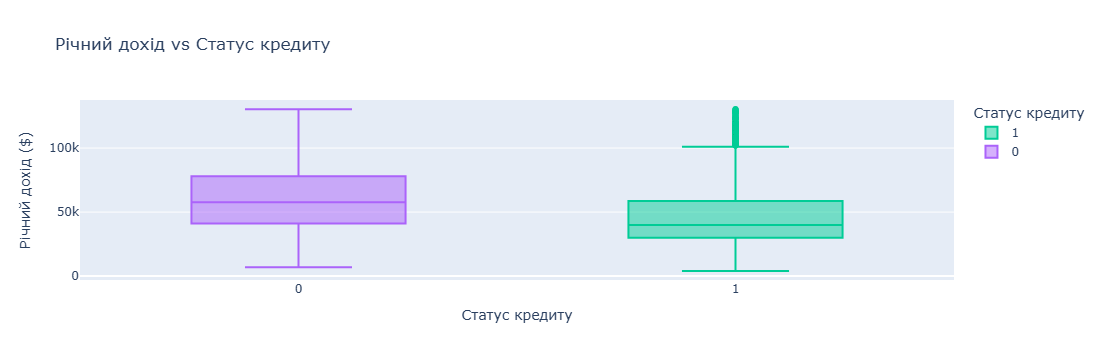

In [58]:
fig = px.box(
    df_clean,
    x='loan_status',
    y='person_income',
    title='Річний дохід vs Статус кредиту',
    labels={'person_income': 'Річний дохід ($)', 'loan_status': 'Статус кредиту'},
    color='loan_status',
    color_discrete_map={'0':'#2ecc71', '1':'#e74c3c'}
)
fig.show()

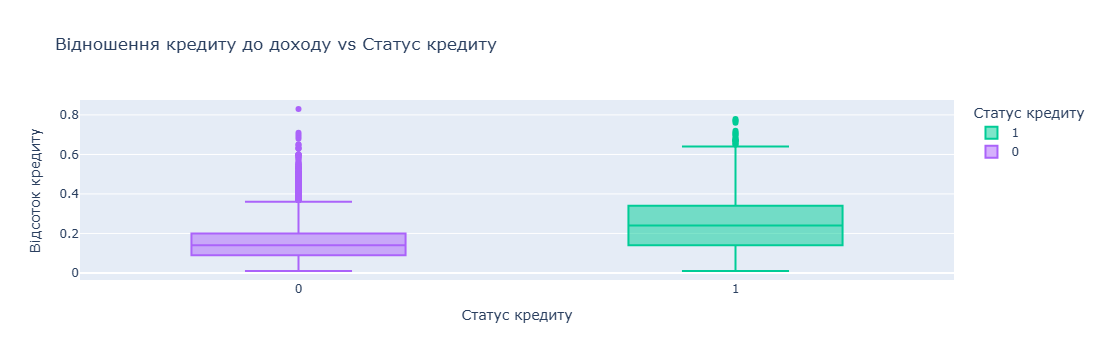

In [65]:
fig = px.box(
    df_clean,
    x='loan_status',
    y='loan_percent_income',
    title='Відношення кредиту до доходу vs Статус кредиту',
    labels={'loan_percent_income': 'Відсоток кредиту', 'loan_status': 'Статус кредиту'},
    color='loan_status',
    color_discrete_map={'0':'#2ecc71', '1':'#e74c3c'}
)
fig.show()

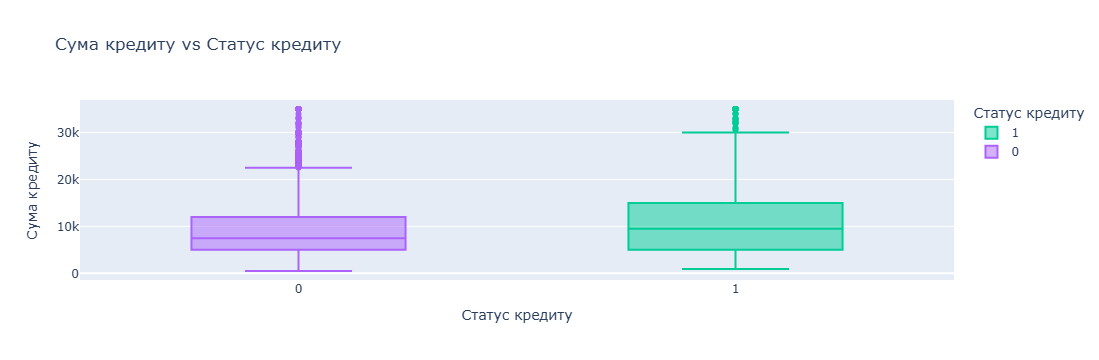

In [64]:
fig = px.box(
    df_clean,
    x='loan_status',
    y='loan_amnt',
     title='Сума кредиту vs Статус кредиту',
     labels={'loan_amnt': 'Сума кредиту', 'loan_status': 'Статус кредиту'},
    color='loan_status',
    color_discrete_map={'0':'#2ecc71', '1':'#e74c3c'}
)
fig.show()


---

## Завдання 3: Аналіз кореляцій та Feature Engineering (3 бали)

**Що потрібно зробити:**
1. Побудуйте матрицю кореляцій для числових змінних.
2. Закодуйте категоріальні змінні.
3. Виберіть фінальний набір ознак, можна лишити всі, якщо ви вважаєте, що це - доцільно.



In [68]:
import matplotlib.pyplot as plt
import seaborn as sns

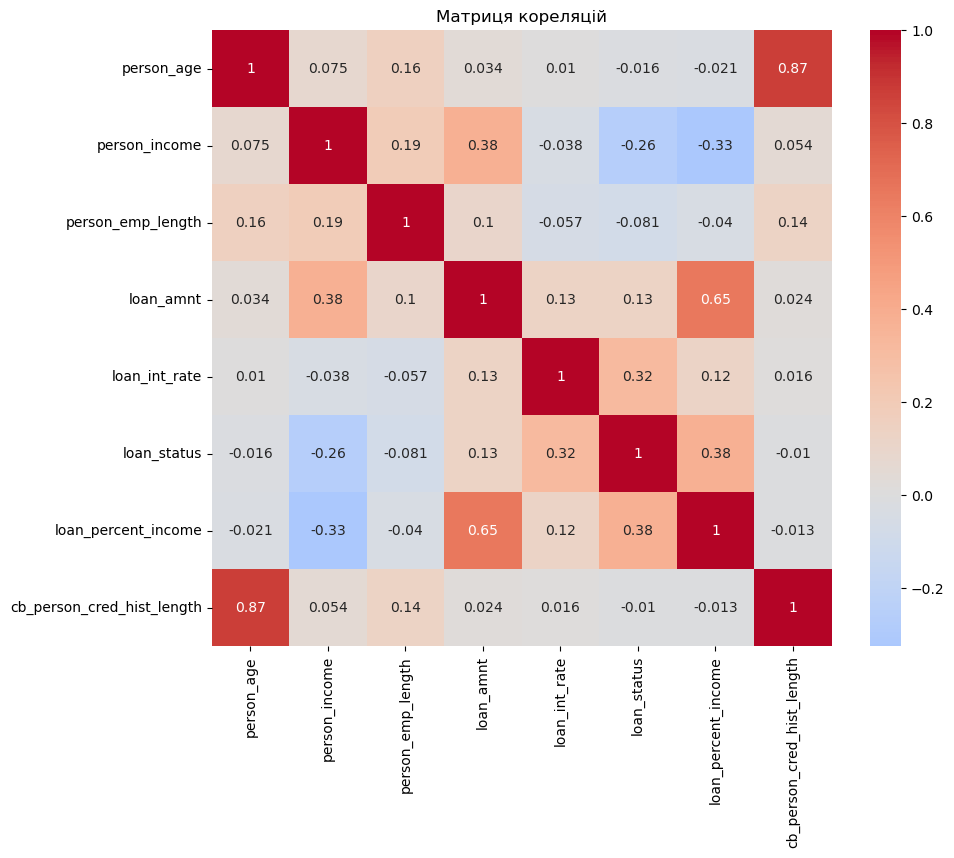

In [69]:
# 1. Матриця кореляцій та heatmap
numeric_columns = df_clean.select_dtypes(include=[np.number]).columns
correlation_matrix = df_clean[numeric_columns].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0)
plt.title('Матриця кореляцій')
plt.show()

In [73]:
all_cat_cols = df.select_dtypes('object').columns.tolist()

# Вибираємо категоріальні колонки для кодування
selected_cat_cols = ['person_home_ownership', 'loan_intent', 'loan_grade', 'cb_person_default_on_file']

# One-hot encoding
df_encoded = pd.get_dummies(df, columns=selected_cat_cols, drop_first=True)

df_encoded.head()

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length,person_home_ownership_OTHER,person_home_ownership_OWN,person_home_ownership_RENT,loan_intent_EDUCATION,loan_intent_HOMEIMPROVEMENT,loan_intent_MEDICAL,loan_intent_PERSONAL,loan_intent_VENTURE,loan_grade_B,loan_grade_C,loan_grade_D,loan_grade_E,loan_grade_F,loan_grade_G,cb_person_default_on_file_Y
0,22,59000,123.0,35000,16.02,1,0.59,3,False,False,True,False,False,False,True,False,False,False,True,False,False,False,True
1,21,9600,5.0,1000,11.14,0,0.10,2,False,True,False,True,False,False,False,False,True,False,False,False,False,False,False
2,25,9600,1.0,5500,12.87,1,0.57,3,False,False,False,False,False,True,False,False,False,True,False,False,False,False,False
3,23,65500,4.0,35000,15.23,1,0.53,2,False,False,True,False,False,True,False,False,False,True,False,False,False,False,False
4,24,54400,8.0,35000,14.27,1,0.55,4,False,False,True,False,False,True,False,False,False,True,False,False,False,False,True


In [74]:
# Виключаємо непотрібні колонки
exclude_cols = ['loan_status'] + all_cat_cols
feature_cols = [col for col in df_encoded.columns if col not in exclude_cols]

X = df_encoded[feature_cols]
y = df_encoded['loan_status']

print(f"Кількість ознак: {X.shape[1]}")
print(f"Розмір вибірки: {X.shape[0]}")

Кількість ознак: 22
Розмір вибірки: 31097


In [75]:
X.head()

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,person_home_ownership_OTHER,person_home_ownership_OWN,person_home_ownership_RENT,loan_intent_EDUCATION,loan_intent_HOMEIMPROVEMENT,loan_intent_MEDICAL,loan_intent_PERSONAL,loan_intent_VENTURE,loan_grade_B,loan_grade_C,loan_grade_D,loan_grade_E,loan_grade_F,loan_grade_G,cb_person_default_on_file_Y
0,22,59000,123.0,35000,16.02,0.59,3,False,False,True,False,False,False,True,False,False,False,True,False,False,False,True
1,21,9600,5.0,1000,11.14,0.10,2,False,True,False,True,False,False,False,False,True,False,False,False,False,False,False
2,25,9600,1.0,5500,12.87,0.57,3,False,False,False,False,False,True,False,False,False,True,False,False,False,False,False
3,23,65500,4.0,35000,15.23,0.53,2,False,False,True,False,False,True,False,False,False,True,False,False,False,False,False
4,24,54400,8.0,35000,14.27,0.55,4,False,False,True,False,False,True,False,False,False,True,False,False,False,False,True



---

## Завдання 4: Підготовка даних та навчання моделі (3 бали)

**Що потрібно зробити:**
1. Розділіть дані на X та y
2. Поділіть на навчальну та тестову вибірки
3. Застосуйте масштабування
4. Навчіть модель логістичної регресії
5. Зробіть прогнози на тренувальній та тестовій вибірках.



In [76]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y  # Важливо! Зберігаємо пропорції класів
)

print(f"Train: {X_train.shape[0]} клієнтів")
print(f"Test: {X_test.shape[0]} клієнтів")
print(f"Відтік в train: {y_train.mean():.1%}")
print(f"Відтік в test: {y_test.mean():.1%}")

Train: 24877 клієнтів
Test: 6220 клієнтів
Відтік в train: 22.4%
Відтік в test: 22.4%


In [77]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [78]:
from sklearn.linear_model import LogisticRegression

# Створюємо та навчаємо модель
model = LogisticRegression(random_state=42, max_iter=1000)
model.fit(X_train_scaled, y_train)

print("Модель навчена!")

Модель навчена!


In [79]:
model

LogisticRegression(max_iter=1000, random_state=42)

In [80]:
# Прогнозуємо класи
y_pred = model.predict(X_test_scaled)

# Прогнозуємо ймовірності
y_pred_proba = model.predict_proba(X_test_scaled)

In [85]:
# Приклад прогнозів для перших 5 клієнтів
sample_predictions = pd.DataFrame({
    'Реальний статус кредиту': y_test.values[:5],
    'Прогноз': y_pred[:5],
    'Ймовірність сплати': y_pred_proba[:5, 0].round(3),
    'Ймовірність дефолту': y_pred_proba[:5, 1].round(3)
})
print(sample_predictions)

   Реальний статус кредиту  Прогноз  Ймовірність сплати  Ймовірність дефолту
0                        0        0               0.969                0.031
1                        0        0               0.986                0.014
2                        0        0               0.965                0.035
3                        0        0               0.965                0.035
4                        0        1               0.165                0.835



---

## Завдання 5: Оцінка якості моделі (4 бали)

**Що потрібно зробити:**
1. Побудуйте confusion matrix.
2. Обчисліть основні метрики (accuracy, precision, recall, f1).
3. Побудуйте ROC-криву та обчисліть AUC
4. Проаналізуйте важливість ознак.
5. Зробіть висновки про якість моделі та які ознаки найбільше впливають на прогноз.


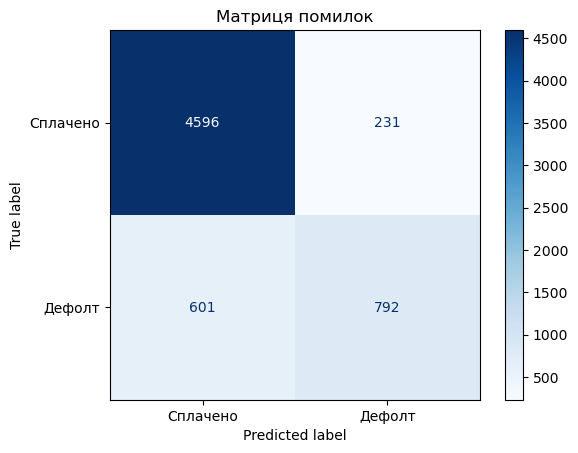

In [87]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Сплачено', 'Дефолт'])
disp.plot(cmap='Blues')
plt.title('Матриця помилок')
plt.show()

In [88]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("МЕТРИКИ ЯКОСТІ МОДЕЛІ:")
print(f"Accuracy (Точність):    {accuracy:.3f}")
print(f"Precision (Влучність):  {precision:.3f}")
print(f"Recall (Повнота):       {recall:.3f}")
print(f"F1-score:               {f1:.3f}")

МЕТРИКИ ЯКОСТІ МОДЕЛІ:
Accuracy (Точність):    0.866
Precision (Влучність):  0.774
Recall (Повнота):       0.569
F1-score:               0.656


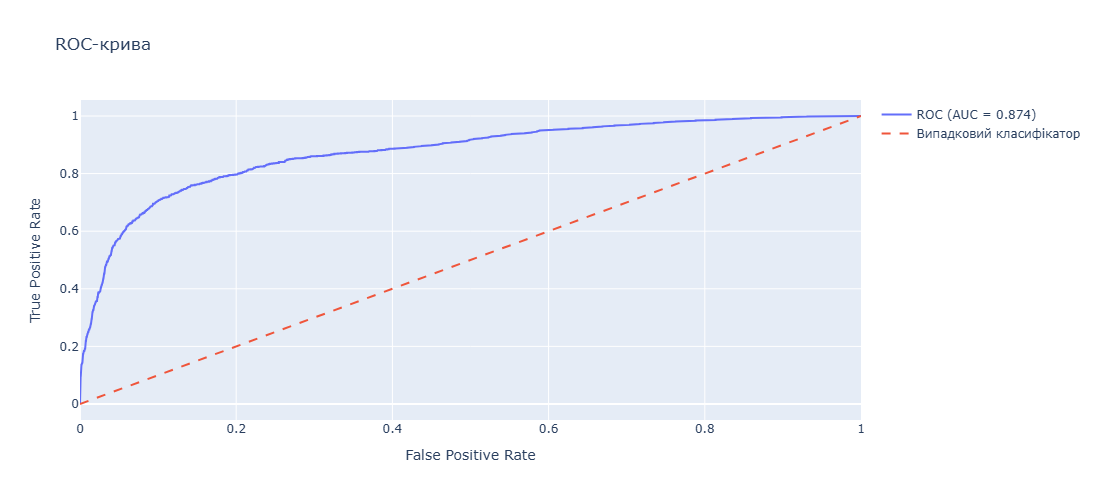

In [89]:
from sklearn.metrics import roc_curve, roc_auc_score

# Обчислюємо ROC
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba[:, 1])
auc = roc_auc_score(y_test, y_pred_proba[:, 1])

# Візуалізація
fig = go.Figure()
fig.add_trace(go.Scatter(x=fpr, y=tpr, mode='lines', name=f'ROC (AUC = {auc:.3f})'))
fig.add_trace(go.Scatter(x=[0, 1], y=[0, 1], mode='lines', line=dict(dash='dash'),
                        name='Випадковий класифікатор'))
fig.update_layout(
    title='ROC-крива',
    xaxis_title='False Positive Rate',
    yaxis_title='True Positive Rate',
    height=500
)
fig.show()

In [91]:
# Отримуємо коефіцієнти моделі
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'coefficient': model.coef_[0],
    'abs_coefficient': np.abs(model.coef_[0])
}).sort_values('abs_coefficient', ascending=False)

feature_importance

,feature,coefficient,abs_coefficient
5,loan_percent_income,1.318553,1.318553
17,loan_grade_D,0.812938,0.812938
3,loan_amnt,-0.546248,0.546248
18,loan_grade_E,0.477536,0.477536
8,person_home_ownership_OWN,-0.459162,0.459162
9,person_home_ownership_RENT,0.404043,0.404043
14,loan_intent_VENTURE,-0.400211,0.400211
10,loan_intent_EDUCATION,-0.326753,0.326753
20,loan_grade_G,0.309888,0.309888
19,loan_grade_F,0.269311,0.269311


Модель показала достатньо хорошу якість класифікації. 
Accuracy - 0.866, висока точність передбачень. 
Precision - 0.774, більшість передбачених дефолтів є правильними. 
Recall = 0.569, модель пропускає частину реальних дефолтів. 
F1-score = 0.656 демонструє баланс між точністю та повнотою.

Аналіз коефіцієнтів:
loan_percent_income (+1.32) - чим більша частка кредиту від доходу, тим більший ризик.
loan_grade - чим гірший кредитний рейтинг, тим більший ризик.
loan_int_rate (+0.16) - чим вищі ставки, тим більш ризикові клієнти.
person_income (-0.17) - чим більший дохід, тим менший ризик.
person_home_ownership_OWN (-0.46) - власне житло зменшує ризик дефолту.


---

## Завдання 6: Оптимізація порогу та бізнес-аналіз (2 бали)

**Що потрібно зробити:**
1. Проаналізуйте метрики precision, recall, F1 при різних порогах класифікації (мінімум - 5 різних порогів). Візуалізуйте як змінюються метрики якості при зміні порогу.
2. Оберіть оптимальний поріг для бізнес-задачі - можна обрати виходячи з попереднього пункту, або додати своїх роздумів і обрати інший.



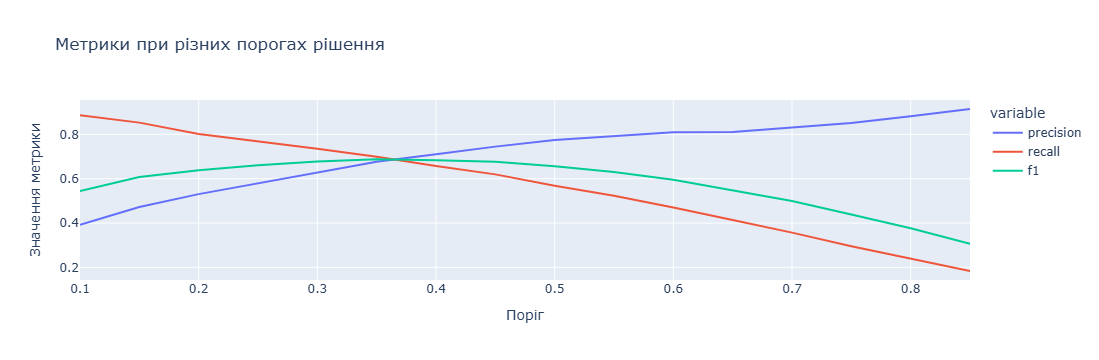

In [100]:
# Аналіз різних порогів
thresholds = np.arange(0.1, 0.9, 0.05)
metrics_by_threshold = []

for threshold in thresholds:
    y_pred_custom = (y_pred_proba[:, 1] >= threshold).astype(int)

    metrics_by_threshold.append({
        'threshold': threshold,
        'precision': precision_score(y_test, y_pred_custom),
        'recall': recall_score(y_test, y_pred_custom),
        'f1': f1_score(y_test, y_pred_custom)
    })

metrics_df = pd.DataFrame(metrics_by_threshold)

# Візуалізація
fig = px.line(
    metrics_df.melt(id_vars='threshold'),
    x='threshold',
    y='value',
    color='variable',
    title='Метрики при різних порогах рішення',
    labels={'value': 'Значення метрики', 'threshold': 'Поріг'},
)
fig.show()

Найкращий баланс між метриками спостерігається при порозі приблизно 0.35–0.4, де досягається максимальне значення F1-score. Зі збільшенням порогу recall зменшується, тоді як precision зростає. 


---

## Завдання 7 (Опціональне): Покращення моделі та висновки (2 бали)

**Що потрібно зробити:**

На цих же даних навчіть DecisionTreeClassifier та RandomForestClassifier. Яка з трьох моделей дає найкращий результат на тестовому наборі?

Поріг класифікації можна для порівняння якостей моделей використовувати стандартний 0.5, або той, що ви виявили, як оптимальний на попередньому кроці.
